# CNN com transformada Wavelet no Pipeline

## Wavelet Haar

Agora, variaremos a wavelet mãe para a Haar (também conhecida como db1) para verificar como o modelo se comporta com uma decomposição mais elementar.

Diferente da Daubechies 4, que busca suavidade através de filtros mais longos, a Haar é a wavelet mais simples e antiga que existe.

A função wavelet Haar tem esse formato:

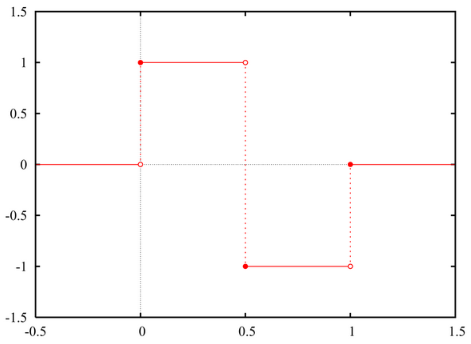


## Implementação da Camada Wavelet Haar

Abaixo código da camada haar implementada.

### Com Wavelet Treinável (requires_grad=True) e Stride = 2

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pywt
import numpy as np

class WaveletPoolingHaar(nn.Module):
    def __init__(self, in_channels):
        super(WaveletPoolingHaar, self).__init__()
        self.in_channels = in_channels
        
        # ================================
        # 1. Wavelet HAAR (db1)
        # ================================
        wavelet = pywt.Wavelet('haar')  
        
        dec_lo = np.array(wavelet.dec_lo)
        dec_hi = np.array(wavelet.dec_hi)

        # ================================
        # 2. Filtros 2D
        # ================================
        ll = np.outer(dec_lo, dec_lo)
        lh = np.outer(dec_lo, dec_hi)
        hl = np.outer(dec_hi, dec_lo)
        hh = np.outer(dec_hi, dec_hi)

        filters = np.stack([ll, lh, hl, hh], axis=0)
        filters = torch.tensor(filters, dtype=torch.float32).unsqueeze(1)

        # ================================
        # 3. Expandir para canais
        # ================================
        initial_weights = filters.repeat(in_channels, 1, 1, 1)

        # congelar inicialmente (melhor estabilidade)
        self.weight = nn.Parameter(initial_weights, requires_grad=True)

        # Haar tem kernel pequeno, ou seja, padding menor
        self.padding = 0

    def forward(self, x):
        return F.conv2d(
            x,
            self.weight,
            stride=2,
            padding=self.padding,
            groups=self.in_channels
        )

## Convolutional Block Attention Module (CBAM)

O Convolutional Block Attention Module é um módulo que:

- refina o mapa de features aplicando atenção em duas dimensões:
    - CANAL → “O QUE é importante”
    - ESPACIAL → “ONDE é importante”

## Channel Attention

In [2]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, H, W = x.size()

        avg_pool = torch.mean(x, dim=(2,3))        # [B, C]
        max_pool, _ = torch.max(x.view(B, C, -1), dim=2)

        avg_out = self.mlp(avg_pool)
        max_out = self.mlp(max_pool)

        out = avg_out + max_out
        out = self.sigmoid(out).view(B, C, 1, 1)

        return x * out

## Spatial Attention

In [3]:
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        maxv, _ = torch.max(x, dim=1, keepdim=True)

        concat = torch.cat([avg, maxv], dim=1)
        att = self.sigmoid(self.conv(concat))

        return x * att

## CBAM completo

In [4]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention()

    def forward(self, x):
        x = self.channel(x)
        x = self.spatial(x)
        return x

## Preparação dos Dados: CLASSIFICAÇÃO + ROI + 5-FOLD + CROSS-VALIDATION

- Classificando as imagnes do Dataset mini-mias

- Carregando dataset para CNN aplicando Data Augmentation (aumento de dados)
    - Efetuado ainda mais variações nas imagens (data augmentation) para conseguir aumentar o dataset.

- Ajustando a **região de interesse (ROI)** para que a rede possa aprender apenas olhando para o artefato.

### Região de interesse - ROI

Em vez de analisar a imagem inteira, o modelo identifica áreas específicas onde há uma alta probabilidade de existir algo interessante (um carro, uma pessoa, uma célula) ou no nosso caso um artefato na região mamária. Essas áreas são as "Regiões de Interesse".

### ESTRUTURA FINAL:

1. Imports + Configuração da Semente (O bloco que escrevi acima).

2. Configurações de Caminhos (PASTA_MIAs, etc).

3. Funções de Apoio (extrair_roi_mias, mostrar_exemplos, ApplyCLAHE).

4. Definição dos Transforms (train_transform e test_transform).

5. Processamento das Imagens (Leitura do PDF e a função processar_para_cv).

6. Criação do Dataset Base:

```python
    dataset_cv = datasets.ImageFolder("dataset_cv", transform=test_transform)
    targets = dataset_cv.targets
    indices = np.arange(len(targets))
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
```

Semente 42 configurada com sucesso!
Total de imagens encontradas: 322
Dataset pronto para CV: 320 imagens.

Mostrando exemplos de ROI...


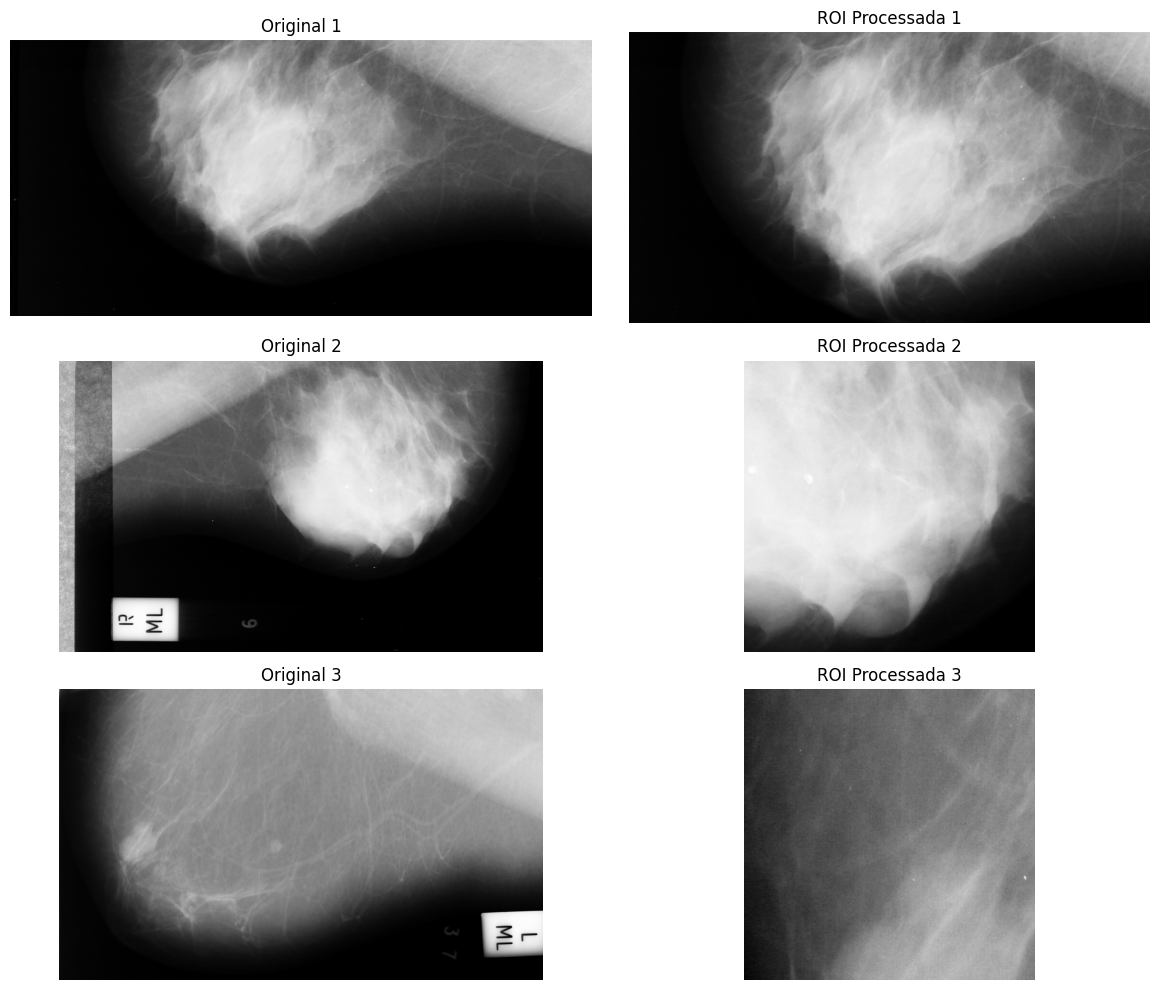


PIPELINE DE DADOS PARA CROSS-VALIDATION VALIDADO!


In [5]:
import os
import random
import shutil
from PyPDF2 import PdfReader
import cv2
import numpy as np
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# === CONFIGURAR SEED =====
def configurar_semente(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Semente {seed} configurada com sucesso!")

configurar_semente(42)
# ============================

# ================================
# CONFIG
# ================================
PASTA_MIAs = "dataset-mias"
OUTPUT_DATASET = "dataset"
PDF_PATH = os.path.join(PASTA_MIAs, "00README.pdf")

# ================================
# 1. PEGAR IMAGENS
# ================================
todas_imagens = sorted([
    f for f in os.listdir(PASTA_MIAs)
    if f.endswith(".pgm")
])

print(f"Total de imagens encontradas: {len(todas_imagens)}")

# ================================
# 2. LER PDF (CLASSE + ROI)
# ================================
reader = PdfReader(PDF_PATH)

texto_total = ""
for pagina in reader.pages:
    txt = pagina.extract_text()
    if txt:
        texto_total += txt + "\n"

linhas = texto_total.split("\n")

mapa_classes = {}
mapa_roi = {}

for linha in linhas:
    linha = linha.strip()

    if linha.startswith("mdb"):
        partes = linha.split()

        if len(partes) >= 3:
            nome = partes[0] + ".pgm"
            classe = partes[2]

            mapa_classes[nome] = classe

            # ROI só se existir
            if len(partes) >= 7:
                try:
                    x = int(partes[4])
                    y = int(partes[5])
                    r = int(partes[6])
                    mapa_roi[nome] = (x, y, r)
                except:
                    mapa_roi[nome] = None
            else:
                mapa_roi[nome] = None
# ================================
# 3. FUNÇÃO ROI
# ================================
def extrair_roi_mias(img, roi_info):
    h, w = img.shape[:2]

    # ================================
    # 1. REMOVER FUNDO (segmentar mama)
    # ================================
    _, thresh = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) > 0:
        c = max(contours, key=cv2.contourArea)
        x_m, y_m, w_m, h_m = cv2.boundingRect(c)

        img = img[y_m:y_m+h_m, x_m:x_m+w_m]

        # ajustar ROI para nova referência
        if roi_info is not None:
            x, y, r = roi_info
            x -= x_m
            y -= y_m
            roi_info = (x, y, r)

    # ================================
    # 2. SE NÃO TEM ROI → retorna mama
    # ================================
    if roi_info is None:
        return img

    x, y, r = roi_info

    # ================================
    # 3. EXPANSÃO INTELIGENTE
    # ================================
    r = int(r * 2.0)

    x1 = max(0, int(x - r))
    y1 = max(0, int(y - r))
    x2 = min(img.shape[1], int(x + r))
    y2 = min(img.shape[0], int(y + r))

    roi = img[y1:y2, x1:x2]

    # ================================
    # 4. VALIDAÇÃO
    # ================================
    if roi.shape[0] < 64 or roi.shape[1] < 64:
        return img

    if np.mean(roi) < 10:
        return img

    return roi

# ================================
# 4. CLASSIFICAÇÃO
# ================================
com_nodulo = []
sem_nodulo = []

for nome in todas_imagens:
    classe = mapa_classes.get(nome, None)

    if classe is None:
        continue
    elif classe == "NORM":
        sem_nodulo.append(nome)
    else:
        com_nodulo.append(nome)

# ================================
# 5. LIMPAR E PREPARAR PASTAS
# ================================
shutil.rmtree(OUTPUT_DATASET, ignore_errors=True)
shutil.rmtree("dataset_cv", ignore_errors=True)
os.makedirs("dataset_cv/com_nodulo", exist_ok=True)
os.makedirs("dataset_cv/sem_nodulo", exist_ok=True)

# ===========================================
# 6. CLASSES AUXILIARES (CLAHE e TRANSFORMS)
# ===========================================
class ApplyCLAHE:
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    def __call__(self, img):
        img_np = np.array(img)
        if img_np.ndim == 3: img_np = img_np[..., 0]
        img_np = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        return Image.fromarray(self.clahe.apply(img_np))

# 1. Transform de TESTE/VALIDAÇÃO (Limpo)
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    ApplyCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# 2. Transform de TREINO (Com Augmentation)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    ApplyCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


# ================================================================
# 7. PROCESSAMENTO PARA CROSS-VALIDATION (Pasta Única)
# ================================================================
def processar_para_cv(lista_com, lista_sem):
    exemplos_para_plot = []
    
    def salvar(lista, subpasta):
        for nome in lista:
            img = cv2.imread(os.path.join(PASTA_MIAs, nome), cv2.IMREAD_GRAYSCALE)
            roi_info = mapa_roi.get(nome)
            img_roi = extrair_roi_mias(img, roi_info)
            
            # Salva na pasta única do CV
            destino = os.path.join(f"dataset_cv/{subpasta}", nome)
            cv2.imwrite(destino, img_roi)
            
            # Captura exemplos para o plot da Parte 8
            if len(exemplos_para_plot) < 6:
                exemplos_para_plot.append((img, img_roi))
                
    salvar(lista_com, "com_nodulo")
    salvar(lista_sem, "sem_nodulo")
    return exemplos_para_plot

# Processa e guarda exemplos para visualização
exemplos_visualizacao = processar_para_cv(com_nodulo, sem_nodulo)

# Carrega o dataset unificado
dataset_cv = datasets.ImageFolder("dataset_cv", transform=test_transform)
print(f"Dataset pronto para CV: {len(dataset_cv)} imagens.")

targets = dataset_cv.targets
indices = np.arange(len(targets))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ================================
# 8. FUNÇÃO PARA MOSTRAR ROI
# ================================
def mostrar_exemplos(exemplos):
    if not exemplos:
        print("Nenhum exemplo para mostrar.")
        return

    plt.figure(figsize=(12, 10))
    
    for i, (orig, roi) in enumerate(exemplos):
        if i >= 3: break # Limita a 3 pares para não poluir a tela
        
        # Original
        plt.subplot(3, 2, 2*i + 1)
        plt.imshow(orig, cmap='gray')
        plt.title(f"Original {i+1}")
        plt.axis('off')

        # ROI Extraída
        plt.subplot(3, 2, 2*i + 2)
        plt.imshow(roi, cmap='gray')
        plt.title(f"ROI Processada {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("\nMostrando exemplos de ROI...")
mostrar_exemplos(exemplos_visualizacao)

print("\nPIPELINE DE DADOS PARA CROSS-VALIDATION VALIDADO!")

## Modelo com Wavelet Haar + CNN + Attention CBAM + ROI

<img src="img/waveletCNN-modelo14.png" width="800" title="Dica de ferramenta">

In [6]:
"""
MODELO COM A WAVELET SUBSTITUINDO O MAXPOOLING, CONVOLUÇÕES E CBAM
"""
class WaveletCNN_HAAR(nn.Module):
    def __init__(self):
        super().__init__()

        self.wavelet_input = WaveletPoolingHaar(in_channels=1)

        self.features = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            CBAM(32), 
            WaveletPoolingHaar(in_channels=32),

            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            CBAM(64), 
            WaveletPoolingHaar(in_channels=64),

            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            CBAM(128), 
            WaveletPoolingHaar(in_channels=128),

        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.wavelet_input(x)
        x = self.features(x)
        x = self.classifier(x)
        return x

## Treino + Avaliação do Modelo

Para avaliar o desempenho da Wavelet CNN no diagnóstico de mamografias, utilizamos a técnica de Validação Cruzada Estratificada em 5 Partes (Stratified 5-Fold Cross-Validation).

### Processo de Treino e Validação:

- Divisão em 5 Grupos: O conjunto de 320 imagens foi dividido em 5 partes iguais.

- Rodízio de Testes: O modelo foi treinado 5 vezes. Em cada vez, ele usou 4 partes para aprender e "escondeu" 1 parte para testar sua eficiência. Assim, todas as imagens foram testadas pelo menos uma vez.

- Estratificação: Garantimos que cada um dos 5 grupos tivesse a mesma proporção de casos "Normais" e "Com Nódulo", evitando que o modelo ficasse viciado em apenas uma classe.

### Garantia de replicação do resultado

- Semente Fixa (Seed 42): Usada para que os resultados sejam sempre os mesmos ao rodar o código, permitindo a conferência dos dados.

- Aumento de Dados (Data Augmentation): Aplicamos rotações e cortes aleatórios apenas no treino. As imagens de teste permaneceram originais para simular um diagnóstico real.

- Métricas de Desempenho: Além da Acurácia, calculamos a Média e o Desvio Padrão do F1-Score e do AUC, garantindo que o modelo é estável e confiável.

In [ ]:
import torch
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

# 1. DEFINIR O DISPOSITIVO (GPU) 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando no dispositivo: {device}")

acc_folds, f1_folds, auc_folds = [], [], []

## Listas para acumular o resultado GLOBAL
todas_labels_global = []
todas_predicoes_global = []

for fold, (train_idx, val_idx) in enumerate(skf.split(indices, targets), 1):
    print(f"\n--- FOLD {fold}/5 ---")
    
    # Criar Subsets
    train_sub = torch.utils.data.Subset(dataset_cv, train_idx)
    val_sub = torch.utils.data.Subset(dataset_cv, val_idx)

    # No treino, usamos aumento de dados (train_transform)
    train_sub.dataset.transform = train_transform
    loader_train = DataLoader(train_sub, batch_size=32, shuffle=True)

    # Na validação (teste do fold), usamos a imagem limpa (test_transform)
    val_sub.dataset.transform = test_transform
    loader_val = DataLoader(val_sub, batch_size=32, shuffle=False)
    # =============================================

    # Inicializa o modelo na GPU
    model = WaveletCNN_HAAR().to(device) 
    optimizer = optim.Adam(model.parameters(), lr=3e-4)
    criterion = nn.CrossEntropyLoss()

    # LOOP DE TREINO (50 épocas)
    for epoch in range(50):
        model.train()
        for imagens, labels in loader_train:
            imagens, labels = imagens.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imagens)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # BLOCO DE TESTE DO FOLD
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for imagens, labels in loader_val:
            imagens, labels = imagens.to(device), labels.to(device)
            outputs = model(imagens)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(probs.cpu().numpy()[:, 1])

    # === MATRIZ DE CONFUSÃO DO FOLD ATUAL ===
    plt.figure(figsize=(5, 4))
    cm_fold = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm_fold, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Sem Nódulo', 'Com Nódulo'], 
                yticklabels=['Sem Nódulo', 'Com Nódulo'])
    plt.title(f'Matriz de Confusão - Fold {fold}')
    plt.ylabel('Real')
    plt.xlabel('Predito')
    plt.show()

    # Acumula para o Global
    todas_labels_global.extend(y_true)
    todas_predicoes_global.extend(y_pred)

    # Cálculo das métricas
    acc_folds.append(accuracy_score(y_true, y_pred))
    f1_folds.append(f1_score(y_true, y_pred, average='weighted'))
    auc_folds.append(roc_auc_score(y_true, y_probs))
    
    print(f"Fold {fold} finalizado. Acc: {acc_folds[-1]*100:.2f}% | F1: {f1_folds[-1]:.4f}")

# RESULTADOS FINAIS
print("\n" + "="*40)
print(f"Média Final Acc: {np.mean(acc_folds)*100:.2f}% ± {np.std(acc_folds)*100:.2f}")
print(f"Média Final F1:  {np.mean(f1_folds):.4f} ± {np.std(f1_folds):.4f}")
print(f"Média Final AUC: {np.mean(auc_folds):.4f} ± {np.std(auc_folds):.4f}")
print("="*40)

# === APÓS O LOOP DE TODOS OS FOLDS: MATRIZ GLOBAL ===
print("\n" + "="*20 + " ANÁLISE FINAL CONSOLIDADA " + "="*20)

plt.figure(figsize=(8, 6))
cm_global = confusion_matrix(todas_labels_global, todas_predicoes_global)
sns.heatmap(cm_global, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem Nódulo', 'Com Nódulo'], 
            yticklabels=['Sem Nódulo', 'Com Nódulo'])
plt.title('Matriz de Confusão Global (Soma de todos os Folds)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

# Relatório estatístico completo
print(classification_report(todas_labels_global, todas_predicoes_global, 
                            target_names=['Sem Nódulo', 'Com Nódulo']))

Treinando no dispositivo: cuda

--- FOLD 1/5 ---
Fold 1 finalizado. Acc: 92.19% | F1: 0.9205

--- FOLD 2/5 ---
Fold 2 finalizado. Acc: 92.19% | F1: 0.9194

--- FOLD 3/5 ---
Fold 3 finalizado. Acc: 89.06% | F1: 0.8871

--- FOLD 4/5 ---
Fold 4 finalizado. Acc: 92.19% | F1: 0.9228

--- FOLD 5/5 ---
Fold 5 finalizado. Acc: 90.62% | F1: 0.9052

Média Final Acc: 91.25% ± 1.25
Média Final F1:  0.9110 ± 0.0134
Média Final AUC: 0.9145 ± 0.0378
